# **Credit Card Default Risk Analysis: Exploratory Data Analysis and Modeling**

**Objective:**
This project focuses on analyzing customer credit data to identify key factors contributing to credit card default. Using the Application and Previous Application datasets, we aim to perform thorough Exploratory Data Analysis (EDA) and build predictive models to assist in risk assessment and decision-making for lending.

**Key Goals:**
* Understand patterns and trends in customer application data

* Handle missing values and perform feature engineering

* Identify driver variables behind loan defaults

* Build classification models to predict potential defaulters

This case study simulates a real-world scenario in banking and financial services, emphasizing the importance of data-driven risk analytics.

**Loading Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Loading Data**

In [2]:
data=pd.read_csv("/kaggle/input/credit-card-transactions-dataset/credit_card_transactions.csv")
data.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


**Basic Observation**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [4]:
data.shape

(1296675, 24)

In [5]:
data.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

In [6]:
data.isnull().sum()

Unnamed: 0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64

In [7]:
data.nunique()

Unnamed: 0               1296675
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
merch_zipcode              28336
dtype: int64

**Data Cleaning**

In [8]:
data['Full_name']=data['first']+' '+data['last']
data['Full_name']

0                 Jennifer Banks
1                 Stephanie Gill
2                 Edward Sanchez
3                   Jeremy White
4                   Tyler Garcia
                   ...          
1296670           Erik Patterson
1296671            Jeffrey White
1296672    Christopher Castaneda
1296673            Joseph Murray
1296674            Jeffrey Smith
Name: Full_name, Length: 1296675, dtype: object

In [9]:
data.drop('Unnamed: 0',axis=1,inplace=True)
data.drop('merch_zipcode',axis=1,inplace=True)
data.drop("trans_date_trans_time",axis=1,inplace=True)
data = data.drop([ 'cc_num', 'first', 'last',
                  'street', 'city', 'state', 'zip', 'job', 'dob', 'trans_num',
                  'unix_time', ], axis=1)

**Data Exploration**

In [10]:
data.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,7.035104e+01,3.853762e+01,-9.022634e+01,8.882444e+04,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.603160e+02,5.075808e+00,1.375908e+01,3.019564e+05,5.109788e+00,1.377109e+01,7.586269e-02
min,1.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.902779e+01,-1.666712e+02,0.000000e+00
25%,9.650000e+00,3.462050e+01,-9.679800e+01,7.430000e+02,3.473357e+01,-9.689728e+01,0.000000e+00
50%,4.752000e+01,3.935430e+01,-8.747690e+01,2.456000e+03,3.936568e+01,-8.743839e+01,0.000000e+00
75%,8.314000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,4.195716e+01,-8.023680e+01,0.000000e+00
max,2.894890e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00


**Exploratory Data Analysis**

In [11]:
categorical_cols = ['merchant', 'category', 'gender']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

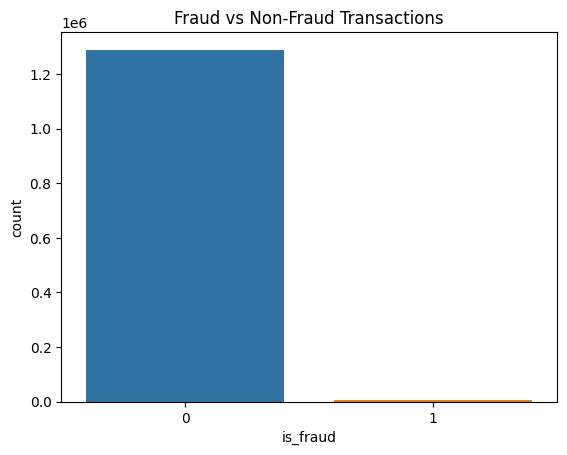

In [12]:
sns.countplot(x='is_fraud', data=data)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


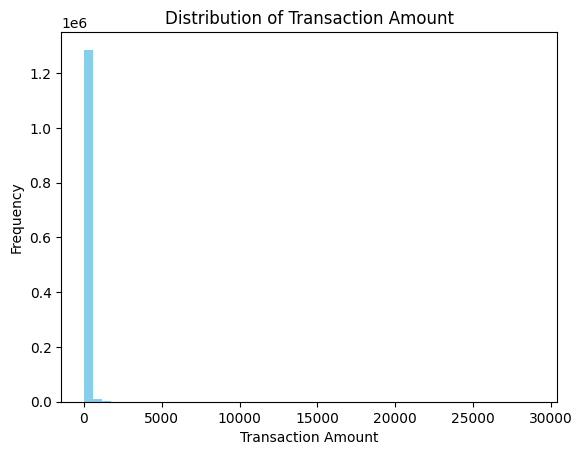

In [13]:
plt.hist(data['amt'], bins=50, color='skyblue')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

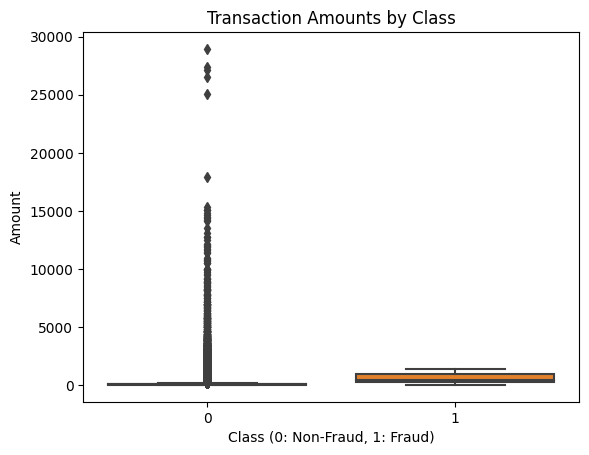

In [14]:
sns.boxplot(x='is_fraud', y='amt', data=data)
plt.title('Transaction Amounts by Class')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Amount')
plt.show()

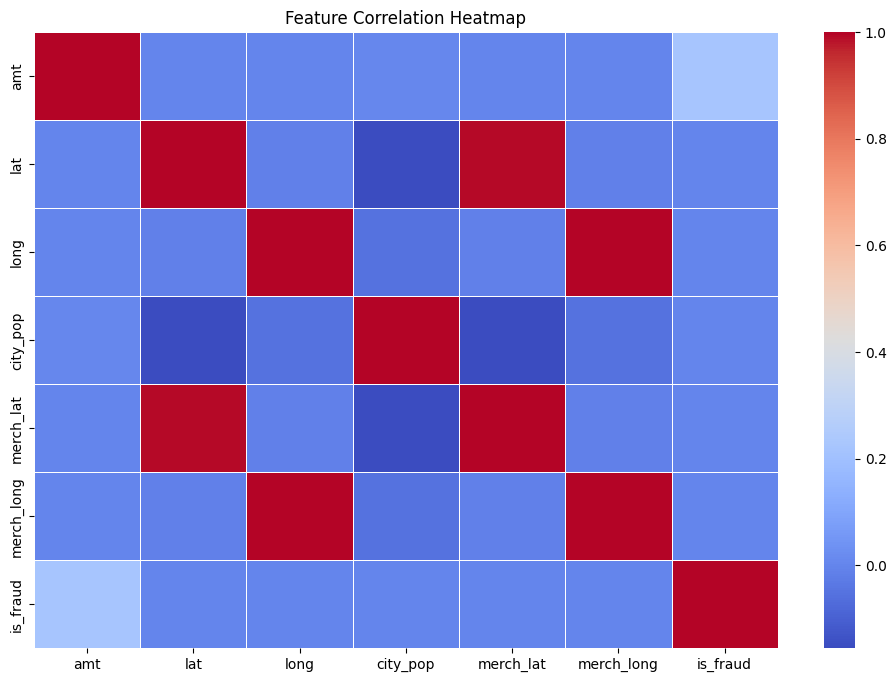

In [15]:
plt.figure(figsize=(12, 8))
numeric_data = data.select_dtypes(include=['number'])
corr = numeric_data.corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

**Model Building**

In [16]:
data = data.select_dtypes(include=['number'])
X = data.drop('is_fraud', axis=1)
#X = data[['amt', 'lat', 'long', 'city_pop', 'category', 'gender']]
y = data['is_fraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9935758767617174
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257815
           1       0.00      0.00      0.00      1520

    accuracy                           0.99    259335
   macro avg       0.50      0.50      0.50    259335
weighted avg       0.99      0.99      0.99    259335



**Decision Tree Classifier**

In [18]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.992133726647001


**K-Neighbour Classifier**

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9946054331270364


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression
y_pred_log = log_model.predict(X_test)
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# Decision Tree
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

# K-Nearest Neighbors (KNN)
y_pred_knn = knn_model.predict(X_test)
print("K-Nearest Neighbors (KNN)")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Logistic Regression
[[257669    146]
 [  1520      0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257815
           1       0.00      0.00      0.00      1520

    accuracy                           0.99    259335
   macro avg       0.50      0.50      0.50    259335
weighted avg       0.99      0.99      0.99    259335

Decision Tree
[[256791   1024]
 [  1016    504]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257815
           1       0.33      0.33      0.33      1520

    accuracy                           0.99    259335
   macro avg       0.66      0.66      0.66    259335
weighted avg       0.99      0.99      0.99    259335

K-Nearest Neighbors (KNN)
[[257431    384]
 [  1015    505]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257815
           1       0.57      0.33      0.42      1520

    accuracy     

In this credit card fraud detection project, the Decision Tree model performed better than Logistic Regression. While both models showed high overall accuracy (99%), Logistic Regression failed to detect any fraud cases (0% recall), making it ineffective for this task. In contrast, the Decision Tree correctly identified 33% of fraudulent transactions, making it a more suitable choice for detecting fraud in an imbalanced dataset.